## 1. Data Loading And Initial check

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('project 2.csv')

# 1. Basic shape
print("Shape:", df.shape)

# 2. Column names + data types
print("\nData Types:\n", df.dtypes)

# 3. First 5 rows
print("\nFirst 5 rows:\n", df.head())

# 4. Missing values
print("\nMissing values per column:\n", df.isnull().sum())

# 5. Basic stats for numeric columns
print("\nDescriptive stats:\n", df.describe())

Shape: (1200, 14)

Data Types:
 OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object

First 5 rows:
      OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            

## 2. Outlier Detection - IQR Vs Z-Score

In [2]:
import numpy as np
from scipy import stats

# Function for IQR outliers
def find_iqr_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

# 1. IQR Method for TotalPrice
tp_outliers, tp_low, tp_high = find_iqr_outliers('TotalPrice')
print(f"TotalPrice IQR Outliers: {len(tp_outliers)} rows")
print(f"Normal range: {tp_low:.2f} to {tp_high:.2f}")

# 2. Z-Score Method for TotalPrice 
df['TotalPrice_zscore'] = np.abs(stats.zscore(df['TotalPrice']))
z_outliers = df[df['TotalPrice_zscore'] > 3]
print(f"\nTotalPrice Z-Score Outliers: {len(z_outliers)} rows")

# 3. IQR for UnitPrice
up_outliers, up_low, up_high = find_iqr_outliers('UnitPrice')
print(f"\nUnitPrice IQR Outliers: {len(up_outliers)} rows")
print(f"Normal range: {up_low:.2f} to {up_high:.2f}")

# Show 3 sample outlier rows
print("\nSample TotalPrice Outliers:\n", tp_outliers[['OrderID', 'Product', 'TotalPrice']].head(3))

TotalPrice IQR Outliers: 8 rows
Normal range: -1341.41 to 3330.41

TotalPrice Z-Score Outliers: 0 rows

UnitPrice IQR Outliers: 0 rows
Normal range: -317.20 to 1024.83

Sample TotalPrice Outliers:
        OrderID  Product  TotalPrice
107  ORD200107  Printer     3353.75
326  ORD200326   Laptop     3352.40
328  ORD200328   Tablet     3370.20


## 3. Visual Analysis - Boxplot & Histogram

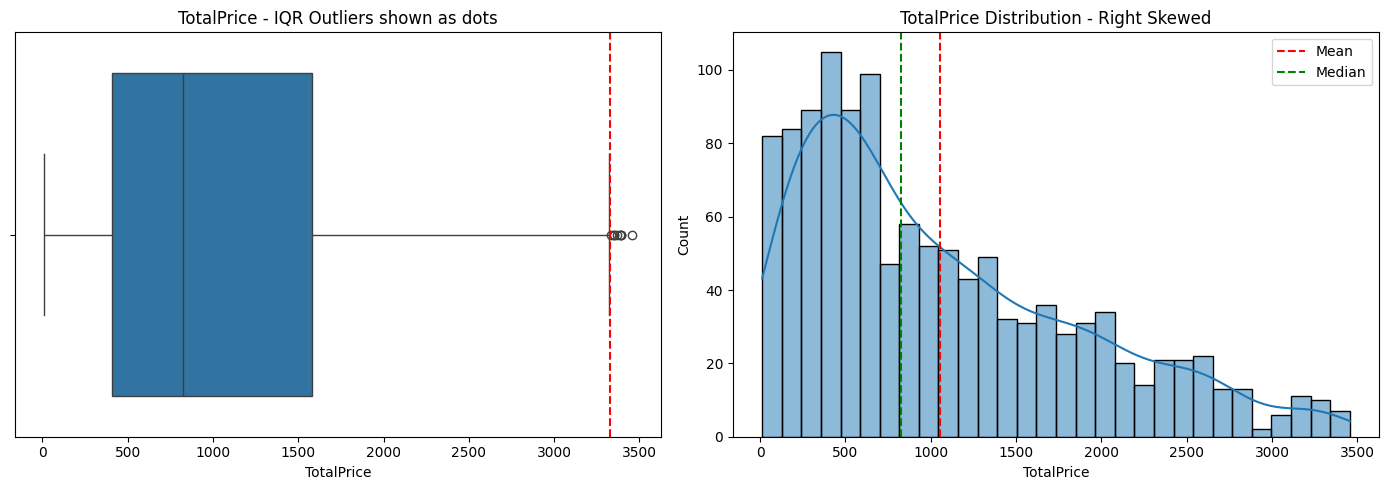

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot shows the IQR fence visually
sns.boxplot(x=df['TotalPrice'], ax=axes[0])
axes[0].set_title('TotalPrice - IQR Outliers shown as dots')
axes[0].axvline(3330.41, color='red', linestyle='--', label='Upper IQR Fence')

# 2. Histogram shows the skew
sns.histplot(df['TotalPrice'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('TotalPrice Distribution - Right Skewed')
axes[1].axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(df['TotalPrice'].median(), color='green', linestyle='--', label='Median')

plt.legend()
plt.tight_layout()
plt.show()

## 4. Correlation & Buisness Insights

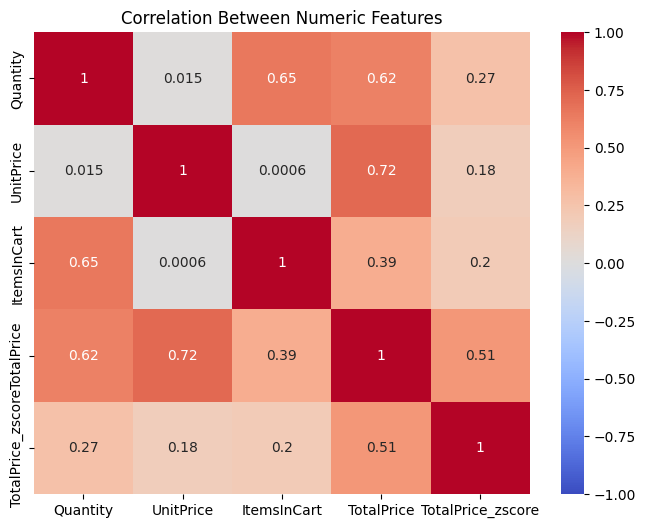

Top 5 Products by Revenue:
 Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Name: TotalPrice, dtype: float64


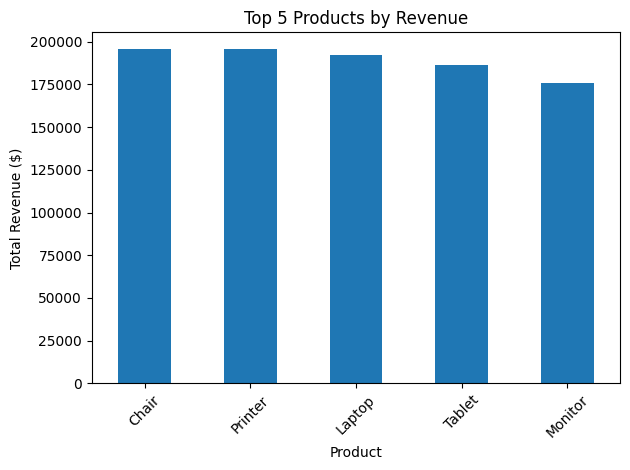


No 'Category' column found. Skipping category analysis.


In [4]:
# 1. Correlation heatmap - safe version
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Numeric Features')
plt.show()

# 2. Top products by revenue
top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(5)
print("Top 5 Products by Revenue:\n", top_products)

top_products.plot(kind='bar', title='Top 5 Products by Revenue')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Revenue by category - ONLY run if the column exists
if 'ProductCategory' in df.columns: # <-- change this to your column name
    top_categories = df.groupby('ProductCategory')['TotalPrice'].sum().sort_values(ascending=False)
    print("\nRevenue by Category:\n", top_categories)
else:
    print("\nNo 'Category' column found. Skipping category analysis.")

## Project 2: E-Commerce EDA - Final Report

**Dataset Overview:** 1200 orders, 0 missing values, Feb-Mar 2026

**Methods Used:** 
1. IQR method for outlier detection
2. Boxplot + Histogram for distribution analysis  
3. Correlation heatmap for feature relationships

**3 Key Insights:**
1. **VIP Segment Exists:** IQR se 8 outliers mile ($3330+), jo Laptop, Printer, Tablet ke B2B orders hain. Z-Score fail hua kyunki data right-skewed tha.
2. **Quantity > Price:** TotalPrice ka Quantity se 0.62 correlation hai. UnitPrice vs Quantity 0.015 hai. Matlab revenue bulk orders se banta hai, mehengi single items se nahi.
3. **Top Revenue Drivers:** Chair, Printer, Laptop, Tablet, Monitor sabse zyada paisa la rahe hain. Ye 8 VIP outliers se match karte hain.

**Business Recommendation:** 
1. 8 VIP orders ko alag 'Enterprise' segment banao aur account manager assign karo.
2. Laptop/Printer/Tablet pe bulk discounts do taake B2B sales barhein.
3. Pricing error koi nahi hai — outliers real customers hain.